In [1]:
# Compare with SMRT
import sys
sys.path.append('E:/exps/lunar_scattering/lunar_regolith_scattering/mores/python')
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C

from VRT import VRT
# from MORES import MORES
# from init_tools import init_surface_from_mores, init_layer_from_mores
from postprocessing import Mueller2sigma0VH
from TransparentSurface import TransparentSurface
# from SmoothSurface import SmoothSurface

from AIEM import AIEM
from RayleighSphere import RayleighSphere
from RayleighSpherekskaeps import RayleighSpherekskaeps
from dieletric_models import diel_soil

In [2]:
freq = 17e9

# common params. for (a) and (b)
epsr2 = 5
delta1 = 0.1e-2
corr_len1 = 1.2e-2
delta2 = 0.5e-2
corr_len2 = 20e-2

# Dry snow Fig. 8.10 (a)
d = 0.45
tau0 = 0.30
a = 0.96
epsr1 = 1.6-1e-3j
# Wet snow Fig. 8.10 (b)
# d = 0.58
# tau0 = 2.5
# a = 0.17
# epsr1 = 1.7-0.005j

ke = tau0 / d
ks = ke * a
ka = ke - ks

c = C.speed_of_light
Lambda = c / freq
k = np.pi * 2 / Lambda
# kdel = k * delta
# kcor = k * corr_len


surface = AIEM(epsilon_r=epsr1, kdel=k*delta1, kcor=k*corr_len1, corr_fun='exp')
layer = RayleighSpherekskaeps(f=freq, epsr_background=epsr1, ks=ks, ka=ka, thickness=d)
subsurface = AIEM(epsilon_r=epsr2/epsr1, kdel=k*delta2, kcor=k*corr_len2, corr_fun='exp')

vrt = VRT(surface, layer, subsurface)
# run model and plot
theta_is = np.linspace(1., 80., 80)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
sig_tmp = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    theta_s = theta_i
    # Mue_surface = vrt.Mue_
    # Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    Mue_sur = vrt.Mue_surface((theta_s, 180, theta_i, 0))
    Mue_vol = vrt.Mue_volume((theta_s, 180, theta_i, 0))
    Mue_sub = vrt.Mue_subsurface((theta_s, 180, theta_i, 0))
    Mue_sub_vol = vrt.Mue_subsurface_volume((theta_s, 180, theta_i, 0))
    Mue_total = Mue_sur + Mue_vol + Mue_sub + Mue_sub_vol
    # Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0)) + vrt.Mue_surface((theta_i, 180, theta_i, 0))
    Mue = Mue_sub
    # Mue = np.diag([1]*4)
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    # sigma0_VVs[i] = 4*np.pi*Mue[0, 0]
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

    M = subsurface.Mue_noncoh_R((theta_i, 180, theta_i, 0))
    sig_tmp[i] = 10*np.log10(4*np.pi*M[0, 0])

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_HV_dB = 10*np.log10(sigma0_HVs)

E:\exps/lunar_scattering/lunar_regolith_scattering/mores/python\VRT.py:54: UserWarning: The ssa (0.6748623651203948) is too high, the first-order iterative VRT solver may obtain inaccurate results.
  warnings.warn("The ssa ({}) is too high, the first-order iterative VRT solver may obtain inaccurate results.".format(ssa))


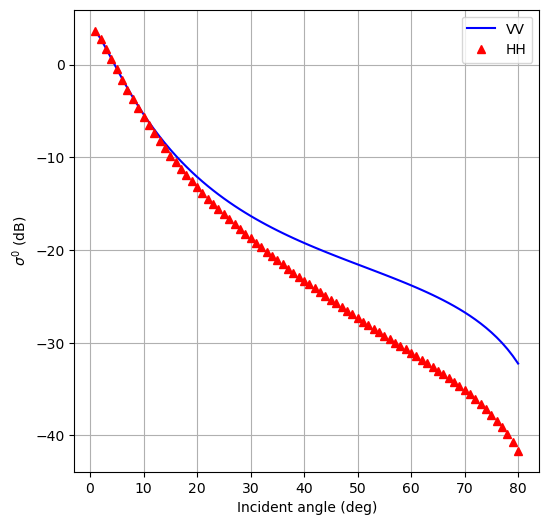

ks:0.6399999999999999, ka:0.026666666666666727, ke:0.6666666666666666, ssa:0.6748623651203948


In [3]:
plt.figure(figsize=(6, 6))
# plt.plot(theta_is, sigma0_VV_dB+10*np.log10(np.cos(np.deg2rad(theta_is))), 'b-', label='VV')
# plt.plot(theta_is, sigma0_HH_dB+10*np.log10(np.cos(np.deg2rad(theta_is))), 'r^', label='HH')
plt.plot(theta_is, sigma0_VV_dB, 'b-', label='VV')
plt.plot(theta_is, sigma0_HH_dB, 'r^', label='HH')
# plt.plot(theta_is, sig_tmp, 'g--', label='tmp')
# plt.ylim(-20, -6)
# plt.yticks(np.arange(-20, 6, 1))
# plt.ylim(-1.5, 0)
# plt.yticks(np.arange(-1.5, 0, 0.5))
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.grid()
plt.show()
layer.print_params()

In [4]:
sigma0_VV_dB[-1]

-32.24260012434493